---

# 🌲 **Random Forest Classification**

## (Türkçesi: Rastgele Orman Sınıflandırması)

---

## 📌 Tanım:

**Random Forest**, birden fazla **Decision Tree (karar ağacı)** oluşturur ve bu ağaçların tahminlerinin **çoğunluk oyuna göre karar verir**.

> Yani: "Bir sürü uzman ağaç eğit, her biri tahmin etsin, sonunda çoğunluk ne diyorsa onu kabul et!"

---

## 🧠 Neden Geliştirildi?

Çünkü **tek bir karar ağacı** çok iyi ezberler (overfitting).
Random Forest:

* Farklı ağaçlar oluşturur (veri ve özellikleri rastgele seçerek)
* Böylece ezber yapma yerine **genellemeyi** öğrenir

---

## ⚙️ Nasıl Çalışır?

1. **Veri setinden rastgele örnekler çekilir (bootstrapping)**

   * Örn: 100 gözlemden rastgele 80’i alınarak bir ağaç eğitilir
2. **Her ağaç rastgele farklı özelliklerle eğitilir**

   * Bu sayede **çeşitlilik (diversity)** oluşur
3. Yeni bir veri geldiğinde her ağaç bir sınıf tahmini yapar
4. **Çoğunluğun kararı (majority vote)** alınır

---

## 🎯 Avantajları:

| Avantaj                           | Açıklama                                |
| --------------------------------- | --------------------------------------- |
| ✅ Aşırı öğrenmeye karşı dayanıklı | Çünkü birçok zayıf modelin birleşimidir |
| ✅ Genelleme gücü yüksek           | Ezber yerine ortalama düşünür           |
| ✅ Büyük veriyle başa çıkabilir    | Paralel çalışabilir                     |
| ✅ Feature importance sağlar       | Hangi özellikler daha önemli öğrenilir  |

---

## ⚠️ Dezavantajları:

| Dezavantaj                   | Açıklama                                          |
| ---------------------------- | ------------------------------------------------- |
| ❌ Yorumlaması zordur         | Tek bir karar ağacı gibi kolay görselleştirilemez |
| ❌ Eğitim süresi uzundur      | Ağaç sayısı arttıkça yavaşlar                     |
| ❌ Hafıza kullanımı yüksektir | Çünkü çok sayıda model saklanır                   |

---

## 📦 Temel Parametreler:

| Parametre        | Açıklama                                    |
| ---------------- | ------------------------------------------- |
| `n_estimators`   | Kaç tane ağaç oluşturulacağı (default: 100) |
| `max_depth`      | Her ağacın maksimum derinliği               |
| `max_features`   | Her ağaç için kaç özellik seçileceği        |
| `bootstrap=True` | Her ağaç için rastgele örnekleme yapılır    |

---

## 💻 Python Örneği (sklearn ile):

```python
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
```

---

## 🔍 Decision Tree vs Random Forest

| Özellik           | Decision Tree       | Random Forest              |
| ----------------- | ------------------- | -------------------------- |
| Model sayısı      | 1                   | Çok (n\_estimators)        |
| Overfitting riski | Yüksek              | Daha düşük                 |
| Hız               | Hızlı               | Daha yavaş ama daha sağlam |
| Yorumlanabilirlik | Kolay (ağaç görsel) | Zor (çoklu ağaç)           |

---

## 📊 Ekstra: Özellik Önem Skoru (Feature Importance)

Random Forest modelleri:

> “Modeli etkileyen en önemli özellikler hangisi?” sorusuna yanıt verir.

```python
importances = model.feature_importances_
```

---

## 🎓 Özetle:

* **Random Forest**, birden fazla karar ağacının birleşimidir.
* Her ağacın tahmini alınır, **çoğunluk kararı verilir**.
* Aşırı öğrenmeye karşı koruma sağlar.
* Gerçek dünyadaki birçok sınıflandırma problemini çözmekte çok başarılıdır.

---

Video sonunda birlikte `n_estimators`, `max_depth`, `feature_importance` gibi parametrelerle oynamak istersen uygulamalı olarak gösterebilirim.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Social_Network_Ads.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [5]:
from sklearn.ensemble import RandomForestClassifier
classifier = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [6]:
print(classifier.predict(sc.transform([[30,87000]])))

[0]


In [7]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


In [8]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[63  5]
 [ 4 28]]


0.91

## Visualising the Training set results

C:\Users\523579\AppData\Local\Temp\ipykernel_46044\4151508945.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


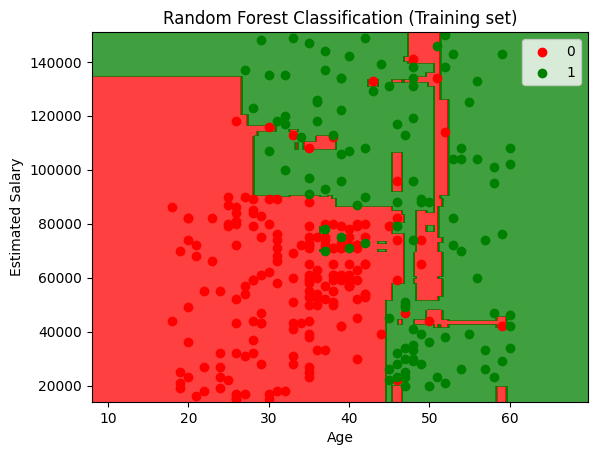

In [9]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_train), y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Random Forest Classification (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

## Visualising the Test set results

C:\Users\523579\AppData\Local\Temp\ipykernel_46044\793843012.py:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)


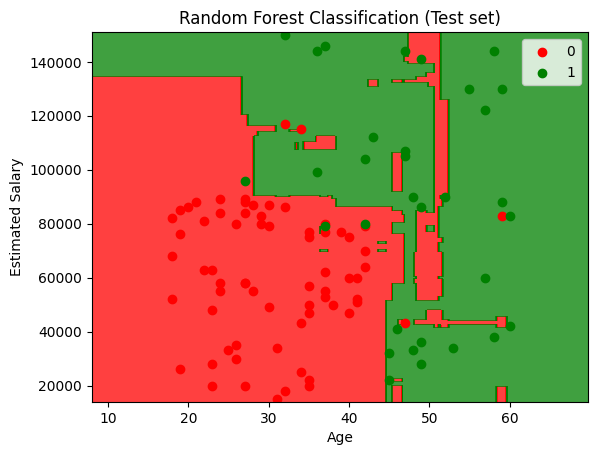

In [10]:
from matplotlib.colors import ListedColormap
X_set, y_set = sc.inverse_transform(X_test), y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 0.25),
                     np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 0.25))
plt.contourf(X1, X2, classifier.predict(sc.transform(np.array([X1.ravel(), X2.ravel()]).T)).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1], c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('Random Forest Classification (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()